# Overview

Name: José Alecander Quishpe Reinoso

Date: 23-06-2026

## Phase 1: Setup & Evaluation

Before testing the models, we need to prepare our data and understand how we are going to measure their performance. To analyze each algorithm, we will use two main visual tools:

* **Confusion Matrix:** This is a table that shows you *exactly* where the model makes mistakes. It breaks down the predictions so you can clearly see the correct guesses (true positives/negatives) and the errors (false alarms or misses).
* **ROC Curve & AUC:** 
    * The **ROC Curve** is a graph that shows the relationship between the model's correct predictions and its false alarms.
    * The **AUC** (Area Under the Curve) summarizes that graph into a single, easy-to-read score: a score of **1.0** means the model is perfect, while a **0.5** (represented by a diagonal line) means the model is useless, just like flipping a random coin.

> **Note:** Run this code block first to generate the dataset and load all the necessary mathematical tools.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# FIXED: All required metrics are imported here so you won't get NameErrors
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc 

# Set global visual style for clean, academic graphs
sns.set_theme(style="whitegrid")

# 1. Generate a synthetic dataset (1000 samples, 20 features)
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into Training (80%) and Testing (20%) sets to prevent overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully prepared. All evaluation metrics loaded.")

Data successfully prepared. All evaluation metrics loaded.


## Phase 2: The Models

### 1. Single Tree (Decision Tree)

**Theoretical Overview:** It creates a single, highly interpretable model by splitting the data based on simple if/then conditional rules. While easy to understand, a single tree is notoriously prone to overfitting—it memorizes the training data and struggles with high variance.

**Graph Analysis:**

* **Confusion Matrix:** You will notice higher numbers in the error squares (the off-diagonal boxes) compared to the advanced ensembles we will test next.
* **ROC Curve:** The curve will likely be somewhat rigid and closer to the diagonal gray line, resulting in a lower AUC score.

Single Tree Accuracy: 0.8750


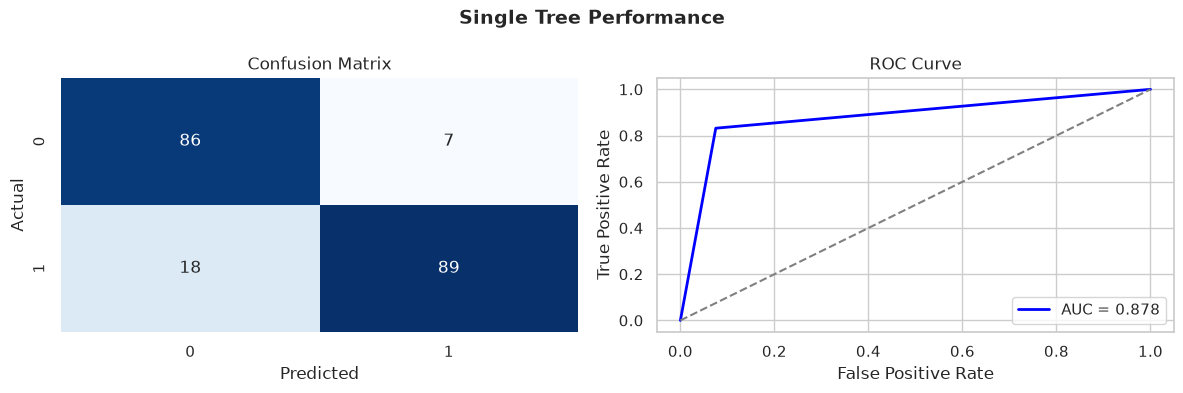

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc 
import matplotlib.pyplot as plt
import seaborn as sns

# Train
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predict classes and probabilities
preds_tree = tree_model.predict(X_test)
probs_tree = tree_model.predict_proba(X_test)[:, 1] # Needed for ROC

print(f"Single Tree Accuracy: {accuracy_score(y_test, preds_tree):.4f}")

# Setup Figure: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Confusion Matrix
cm_tree = confusion_matrix(y_test, preds_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_tree)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

fig.suptitle('Single Tree Performance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()